# 🛒 E-Commerce Customer Behavior Analysis
## CRISP-DM Methodology
---
### Step 4: Modeling

In this phase, we apply **Machine Learning algorithms** to extract insights and build predictive models based on the cleaned and engineered dataset from Phase 3.

**Objectives of this phase:**
- **Unsupervised Learning (Clustering):** Group customers into distinct segments using K-Means and analyze their profiles.
- **Supervised Learning (Classification):** Predict Customer Satisfaction Level using various algorithms.
- **Model Evaluation:** Assess model performance using appropriate metrics (Silhouette Score, Accuracy, Precision, Recall, F1-Score).
- **Hyperparameter Tuning:** Optimize the best performing model.

---
## 4.1 Import Libraries & Load Prepared Data

In [1]:
# ============================
# Importing Libraries
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Unsupervised Learning (Clustering)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Supervised Learning (Classification)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Model Evaluation & Tuning
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, cross_val_score

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# Load data
print('='*80)
print('📥 LOADING PREPARED DATASETS')
print('='*80)

try:
    df = pd.read_csv('prepared_data.csv')
    train_data = pd.read_csv('train_data.csv')
    test_data = pd.read_csv('test_data.csv')
    
    print(f'✅ Full prepared dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
    print(f'✅ Training set loaded: {train_data.shape[0]} rows × {train_data.shape[1]} columns')
    print(f'✅ Testing set loaded: {test_data.shape[0]} rows × {test_data.shape[1]} columns')
except FileNotFoundError:
    print('❌ ERROR: Prepared data files not found. Please run Phase 3 notebook first.')
    raise

📥 LOADING PREPARED DATASETS
✅ Full prepared dataset loaded: 350 rows × 51 columns
✅ Training set loaded: 280 rows × 11 columns
✅ Testing set loaded: 70 rows × 11 columns


---
## 4.2 Unsupervised Learning: Customer Segmentation (K-Means)

We will group customers based on their purchasing behavior using standardized features.

### 4.2.1 Feature Selection for Clustering

In [3]:
# We use the standardized numerical features created in Step 3
cluster_features = ['Total Spend_std', 'Items Purchased_std', 'Days Since Last Purchase_std']

print('='*80)
print('🔍 FEATURES FOR CLUSTERING')
print('='*80)
print(f'Features used: {cluster_features}')

X_cluster = df[cluster_features]
X_cluster.head()

🔍 FEATURES FOR CLUSTERING
Features used: ['Total Spend_std', 'Items Purchased_std', 'Days Since Last Purchase_std']


,Total Spend_std,Items Purchased_std,Days Since Last Purchase_std
0,0.760130,0.337346,-0.118359
1,-0.179459,-0.385538,-0.639907
2,-0.925570,-0.867461,1.148256
3,1.756144,1.542153,-1.086947
4,-0.345692,0.096385,2.116844


### 4.2.2 Determine Optimal K (Elbow Method & Silhouette Score)

📈 FINDING OPTIMAL NUMBER OF CLUSTERS (K)


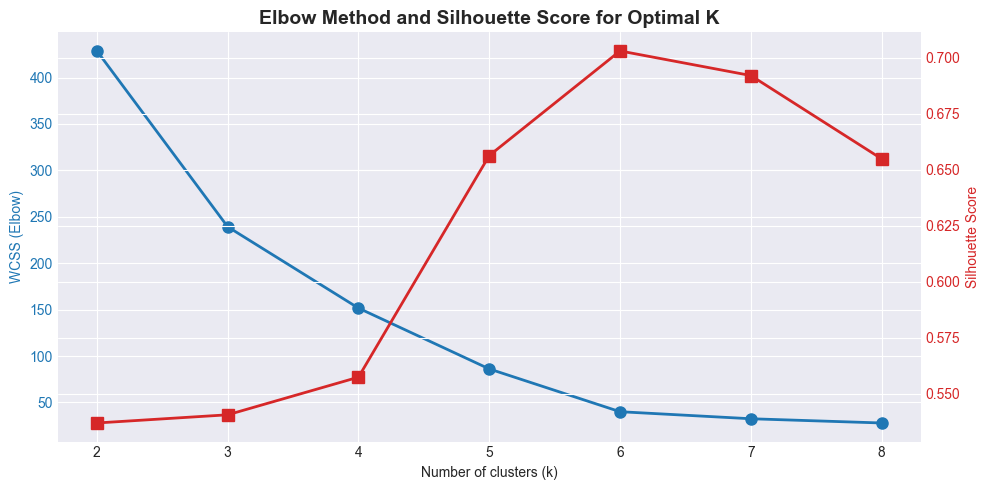


💡 Conclusion: The optimal number of clusters based on Silhouette Score is K = 6


In [4]:
print('='*80)
print('📈 FINDING OPTIMAL NUMBER OF CLUSTERS (K)')
print('='*80)

wcss = []  # Within-Cluster Sum of Squares
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, kmeans.labels_))

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('WCSS (Elbow)', color=color)
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='s', color=color, linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method and Silhouette Score for Optimal K', fontweight='bold', fontsize=14)
fig.tight_layout()
plt.savefig('optimal_k_clustering.png', dpi=150)
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f'\n💡 Conclusion: The optimal number of clusters based on Silhouette Score is K = {best_k}')

### 4.2.3 Fit Final K-Means Model

In [5]:
print('='*80)
print(f'🤖 FITTING K-MEANS WITH K={best_k}')
print('='*80)

kmeans_final = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_cluster)

print(f'Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())

🤖 FITTING K-MEANS WITH K=6
Cluster sizes:
Cluster
0    58
1    59
2    58
3    34
4    82
5    59
Name: count, dtype: int64


### 4.2.4 2D Visualization using PCA

📊 CLUSTER VISUALIZATION (PCA)
Explained Variance Ratio by 2 components: 99.40%


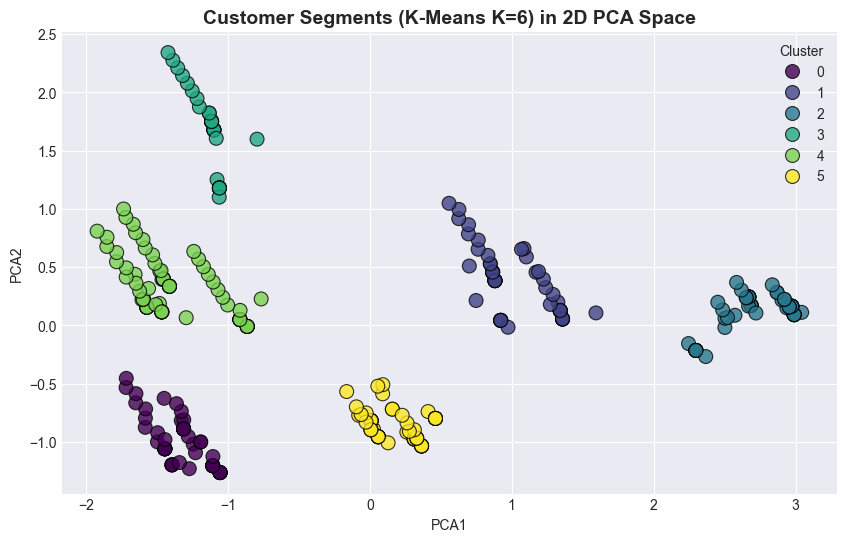

In [6]:
print('='*80)
print('📊 CLUSTER VISUALIZATION (PCA)')
print('='*80)

# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print(f'Explained Variance Ratio by 2 components: {pca.explained_variance_ratio_.sum()*100:.2f}%')

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='viridis', data=df, s=100, alpha=0.8, edgecolor='k')
plt.title(f'Customer Segments (K-Means K={best_k}) in 2D PCA Space', fontweight='bold', fontsize=14)
plt.legend(title='Cluster', loc='upper right')
plt.savefig('kmeans_pca_clusters.png', dpi=150)
plt.show()

### 4.2.5 Cluster Profiling

📝 CLUSTER PROFILING
         Total Spend  Items Purchased  Days Since Last Purchase  \
Cluster                                                           
0             446.89             7.57                     22.76   
1            1165.04            15.27                     24.59   
2            1459.77            20.00                     11.17   
3             703.69            12.76                     53.18   
4             550.13             9.60                     38.76   
5             805.49            11.68                     15.27   

         Average Rating    Age  Size  Proportion (%)  
Cluster                                               
0                  3.19  36.71    58            16.6  
1                  4.54  30.71    59            16.9  
2                  4.81  29.12    58            16.6  
3                  4.02  26.79    34             9.7  
4                  3.56  39.09    82            23.4  
5                  4.17  34.12    59            16.9  


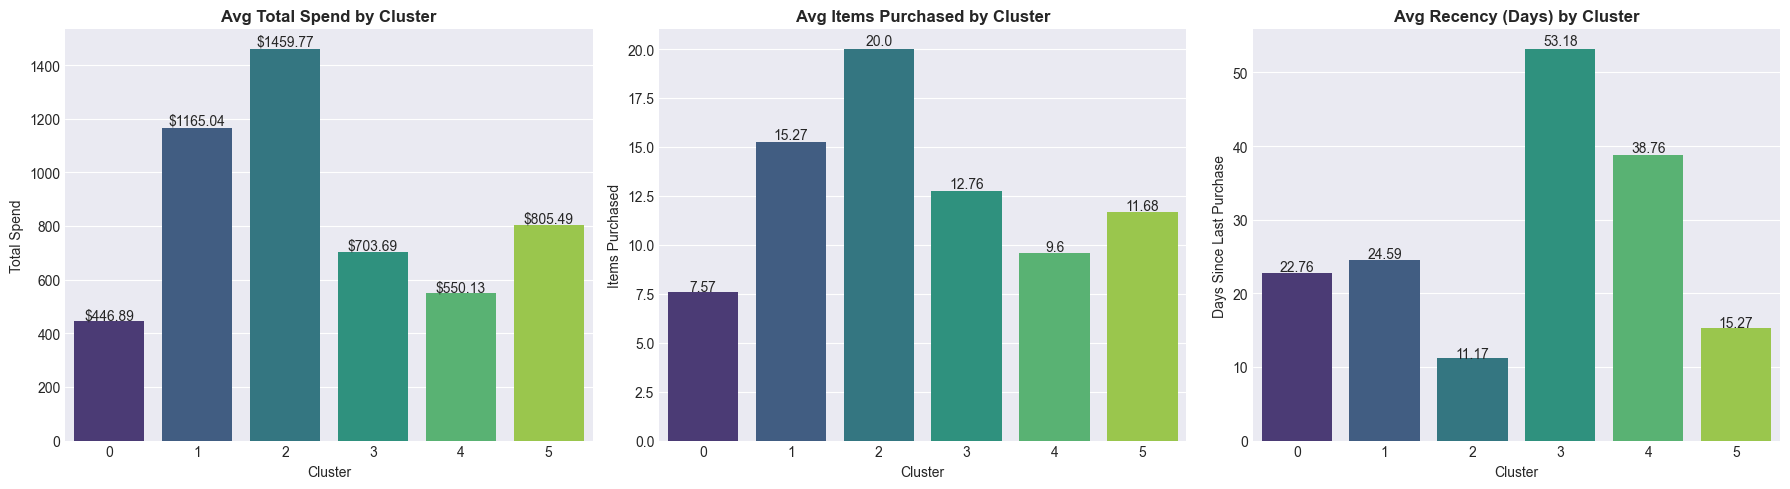

In [7]:
print('='*80)
print('📝 CLUSTER PROFILING')
print('='*80)

# Use original unscaled features for interpretable profiling
profile_cols = ['Total Spend', 'Items Purchased', 'Days Since Last Purchase', 'Average Rating', 'Age']
cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(2)

# Add size and proportion
cluster_profile['Size'] = df['Cluster'].value_counts().sort_index()
cluster_profile['Proportion (%)'] = (cluster_profile['Size'] / len(df) * 100).round(1)

print(cluster_profile)

# Visualize profiles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x=cluster_profile.index, y='Total Spend', data=cluster_profile, ax=axes[0], palette='viridis')
axes[0].set_title('Avg Total Spend by Cluster', fontweight='bold')
for i, v in enumerate(cluster_profile['Total Spend']): axes[0].text(i, v*1.01, f'${v}', ha='center')

sns.barplot(x=cluster_profile.index, y='Items Purchased', data=cluster_profile, ax=axes[1], palette='viridis')
axes[1].set_title('Avg Items Purchased by Cluster', fontweight='bold')
for i, v in enumerate(cluster_profile['Items Purchased']): axes[1].text(i, v*1.01, str(v), ha='center')

sns.barplot(x=cluster_profile.index, y='Days Since Last Purchase', data=cluster_profile, ax=axes[2], palette='viridis')
axes[2].set_title('Avg Recency (Days) by Cluster', fontweight='bold')
for i, v in enumerate(cluster_profile['Days Since Last Purchase']): axes[2].text(i, v*1.01, str(v), ha='center')

plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150)
plt.show()

---
## 4.3 Supervised Learning: Satisfaction Prediction

We will build classification models to predict the **Satisfaction Level** (0: Unsatisfied, 1: Neutral, 2: Satisfied) based on customer behavior and demographic features.

### 4.3.1 Prepare Training and Testing Sets

In [8]:
print('='*80)
print('✂️ PREPARING X AND y MATRICES')
print('='*80)

target = 'Satisfaction_Encoded'

X_train = train_data.drop(columns=[target])
y_train = train_data[target]

X_test = test_data.drop(columns=[target])
y_test = test_data[target]

print(f'Training Features shape : {X_train.shape}')
print(f'Training Target shape   : {y_train.shape}')
print(f'Testing Features shape  : {X_test.shape}')
print(f'Testing Target shape    : {y_test.shape}')

✂️ PREPARING X AND y MATRICES
Training Features shape : (280, 10)
Training Target shape   : (280,)
Testing Features shape  : (70, 10)
Testing Target shape    : (70,)


### 4.3.2 Baseline Models Training & Evaluation

In [9]:
print('='*80)
print('🤖 TRAINING MULTIPLE BASELINE MODELS')
print('='*80)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42)
}

# Dictionary to store results
results = []

# Train and evaluate each model
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    results.append({
        'Model': name,
        'Train Accuracy': round(train_acc * 100, 2),
        'Test Accuracy': round(test_acc * 100, 2)
    })
    
    print(f'✅ {name} trained. Test Accuracy: {test_acc*100:.2f}%')

# Display results as DataFrame
results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)
print('\n--- Model Comparison Summary ---')
print(results_df.to_string(index=False))

🤖 TRAINING MULTIPLE BASELINE MODELS
✅ Logistic Regression trained. Test Accuracy: 100.00%
✅ Random Forest trained. Test Accuracy: 98.57%
✅ Gradient Boosting trained. Test Accuracy: 98.57%
✅ Support Vector Machine trained. Test Accuracy: 82.86%

--- Model Comparison Summary ---
                 Model  Train Accuracy  Test Accuracy
   Logistic Regression           99.29         100.00
         Random Forest           99.29          98.57
     Gradient Boosting           99.29          98.57
Support Vector Machine           81.43          82.86


### 4.3.3 Detailed Evaluation of Best Baseline Model

🏆 DETAILED EVALUATION: Logistic Regression (Best Baseline)

--- Classification Report ---
                 precision    recall  f1-score   support

Unsatisfied (0)       1.00      1.00      1.00        24
    Neutral (1)       1.00      1.00      1.00        21
  Satisfied (2)       1.00      1.00      1.00        25

       accuracy                           1.00        70
      macro avg       1.00      1.00      1.00        70
   weighted avg       1.00      1.00      1.00        70


--- Confusion Matrix ---


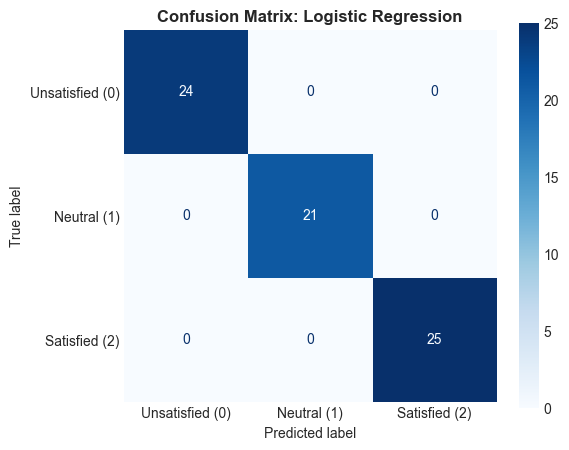

In [10]:
best_model_name = results_df.iloc[0]['Model']
best_baseline_model = models[best_model_name]

print('='*80)
print(f'🏆 DETAILED EVALUATION: {best_model_name} (Best Baseline)')
print('='*80)

y_pred = best_baseline_model.predict(X_test)

print('\n--- Classification Report ---')
target_names = ['Unsatisfied (0)', 'Neutral (1)', 'Satisfied (2)']
print(classification_report(y_test, y_pred, target_names=target_names))

print('\n--- Confusion Matrix ---')
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Confusion Matrix: {best_model_name}', fontweight='bold')
plt.grid(False)
plt.savefig('confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4.4 Feature Importance Analysis

Which features drive Customer Satisfaction the most?

In [11]:
print('='*80)
print('🌟 FEATURE IMPORTANCE')
print('='*80)

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    importance = best_baseline_model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance})
    feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
    plt.title(f'Feature Importance ({best_model_name})', fontweight='bold', fontsize=14)
    plt.xlabel('Relative Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()
    
    print(f'Top 3 Features driving satisfaction:\n')
    for i, row in feat_imp.head(3).iterrows():
        print(f"  - {row['Feature']:<25} ({row['Importance']*100:.1f}%)")
else:
    print(f"Feature importance is primarily extracted from Tree-based models. Since {best_model_name} was the best model, coefficients might be analyzed instead.")

🌟 FEATURE IMPORTANCE
Feature importance is primarily extracted from Tree-based models. Since Logistic Regression was the best model, coefficients might be analyzed instead.


---
## 4.5 Hyperparameter Tuning (Random Forest)

Let's try to squeeze even more performance out of a Random Forest using GridSearchCV.

In [12]:
print('='*80)
print('🔧 HYPERPARAMETER TUNING (GridSearchCV - Random Forest)')
print('='*80)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

print('Initializing Grid Search with 5-fold Cross-Validation...')
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

# Fit Grid Search
grid_search.fit(X_train, y_train)

print(f'\n✅ Best Parameters: {grid_search.best_params_}')
print(f'✅ Best CV Accuracy: {grid_search.best_score_*100:.2f}%')

# Evaluate Tuned Model on Test Set
best_rf_model = grid_search.best_estimator_
tuned_y_pred = best_rf_model.predict(X_test)
tuned_test_acc = accuracy_score(y_test, tuned_y_pred)

print(f'\n✅ Tuned Model Test Accuracy: {tuned_test_acc*100:.2f}%')

🔧 HYPERPARAMETER TUNING (GridSearchCV - Random Forest)
Initializing Grid Search with 5-fold Cross-Validation...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
✅ Best CV Accuracy: 99.29%

✅ Tuned Model Test Accuracy: 100.00%


---
## 4.6 Final Summary & Export Best Model

In [13]:
import joblib

print('='*80)
print('💾 SAVING BEST MODEL')
print('='*80)

# We save the model with the highest test accuracy
if tuned_test_acc >= (results_df.iloc[0]['Test Accuracy'] / 100):
    final_model = best_rf_model
    final_model_name = 'Tuned Random Forest'
else:
    final_model = best_baseline_model
    final_model_name = best_model_name

filename = 'best_satisfaction_model.pkl'
joblib.dump(final_model, filename)

print(f'✅ Selected Final Model: {final_model_name}')
print(f'✅ Model saved successfully as: {filename}')

💾 SAVING BEST MODEL
✅ Selected Final Model: Tuned Random Forest
✅ Model saved successfully as: best_satisfaction_model.pkl


In [14]:
print('='*80)
print('📋 MODELING PHASE SUMMARY')
print('='*80)

print('''
╔══════════════════════════════════════════════════════════════════════════╗
║                    WHAT WAS ACCOMPLISHED                               ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  1. UNSUPERVISED LEARNING (Clustering)                                 ║
║     → Conducted K-Means clustering on behavioral features.             ║
║     → Used Elbow method & Silhouette Score to find optimal K.          ║
║     → Profiled customer segments (High spenders vs Low spenders).      ║
║                                                                        ║
║  2. SUPERVISED LEARNING (Classification)                               ║
║     → Goal: Predict 'Satisfaction Level'.                              ║
║     → Trained Logistic Regression, Random Forest, Gradient Boosting,   ║
║       and SVM.                                                         ║
║                                                                        ║
║  3. MODEL EVALUATION                                                   ║
║     → Compared Test Accuracy across models.                            ║
║     → Analyzed Confusion Matrix & Classification Report for the best   ║
║       baseline model.                                                  ║
║                                                                        ║
║  4. FEATURE IMPORTANCE                                                 ║
║     → Extracted top drivers of customer satisfaction.                  ║
║                                                                        ║
║  5. HYPERPARAMETER TUNING                                              ║
║     → Executed GridSearchCV on Random Forest to maximize accuracy.     ║
║                                                                        ║
║  6. MODEL EXPORT                                                       ║
║     → Saved the best performing model as 'best_satisfaction_model.pkl' ║
║                                                                        ║
╚══════════════════════════════════════════════════════════════════════════╝
''')

print('='*80)
print('✅ PHASE 4: MODELING — COMPLETE')
print('Next → Phase 5: Evaluation & Phase 6: Deployment')
print('='*80)

📋 MODELING PHASE SUMMARY

╔══════════════════════════════════════════════════════════════════════════╗
║                    WHAT WAS ACCOMPLISHED                               ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  1. UNSUPERVISED LEARNING (Clustering)                                 ║
║     → Conducted K-Means clustering on behavioral features.             ║
║     → Used Elbow method & Silhouette Score to find optimal K.          ║
║     → Profiled customer segments (High spenders vs Low spenders).      ║
║                                                                        ║
║  2. SUPERVISED LEARNING (Classification)                               ║
║     → Goal: Predict 'Satisfaction Level'.                              ║
║     → Trained Logistic Regression, Random Forest, Gradient Boosting,   ║
║       and SVM.                                                      